In [1]:
import os
os.listdir()

['.ipynb_checkpoints',
 'daily_energy.csv',
 'energy.db',
 'energy_dataset.csv',
 'hourly_energy.csv',
 'monthly_energy.csv',
 'project.ipynb']

In [2]:
import pandas as pd
df = pd.read_csv("energy_dataset.csv")
df.head()

,time,generation biomass,generation fossil brown coal/lignite,generation fossil coal-derived gas,generation fossil gas,generation fossil hard coal,generation fossil oil,generation fossil oil shale,generation fossil peat,generation geothermal,...,generation waste,generation wind offshore,generation wind onshore,forecast solar day ahead,forecast wind offshore eday ahead,forecast wind onshore day ahead,total load forecast,total load actual,price day ahead,price actual
0,2015-01-01 00:00:00+01:00,447.0,329.0,0.0,4844.0,4821.0,162.0,0.0,0.0,0.0,...,196.0,0.0,6378.0,17.0,NaN,6436.0,26118.0,25385.0,50.10,65.41
1,2015-01-01 01:00:00+01:00,449.0,328.0,0.0,5196.0,4755.0,158.0,0.0,0.0,0.0,...,195.0,0.0,5890.0,16.0,NaN,5856.0,24934.0,24382.0,48.10,64.92
2,2015-01-01 02:00:00+01:00,448.0,323.0,0.0,4857.0,4581.0,157.0,0.0,0.0,0.0,...,196.0,0.0,5461.0,8.0,NaN,5454.0,23515.0,22734.0,47.33,64.48
3,2015-01-01 03:00:00+01:00,438.0,254.0,0.0,4314.0,4131.0,160.0,0.0,0.0,0.0,...,191.0,0.0,5238.0,2.0,NaN,5151.0,22642.0,21286.0,42.27,59.32
4,2015-01-01 04:00:00+01:00,428.0,187.0,0.0,4130.0,3840.0,156.0,0.0,0.0,0.0,...,189.0,0.0,4935.0,9.0,NaN,4861.0,21785.0,20264.0,38.41,56.04


In [3]:
df.columns

Index(['time', 'generation biomass', 'generation fossil brown coal/lignite',
       'generation fossil coal-derived gas', 'generation fossil gas',
       'generation fossil hard coal', 'generation fossil oil',
       'generation fossil oil shale', 'generation fossil peat',
       'generation geothermal', 'generation hydro pumped storage aggregated',
       'generation hydro pumped storage consumption',
       'generation hydro run-of-river and poundage',
       'generation hydro water reservoir', 'generation marine',
       'generation nuclear', 'generation other', 'generation other renewable',
       'generation solar', 'generation waste', 'generation wind offshore',
       'generation wind onshore', 'forecast solar day ahead',
       'forecast wind offshore eday ahead', 'forecast wind onshore day ahead',
       'total load forecast', 'total load actual', 'price day ahead',
       'price actual'],
      dtype='object')

In [4]:


df['time'] = pd.to_datetime(df['time'], utc=True, errors='coerce')


df = df.dropna(subset=['time', 'total load actual'])


df['hour'] = df['time'].dt.hour
df['day'] = df['time'].dt.day
df['month'] = df['time'].dt.month

In [5]:
df[['time','hour','day','month']].head()

,time,hour,day,month
0,2014-12-31 23:00:00+00:00,23,31,12
1,2015-01-01 00:00:00+00:00,0,1,1
2,2015-01-01 01:00:00+00:00,1,1,1
3,2015-01-01 02:00:00+00:00,2,1,1
4,2015-01-01 03:00:00+00:00,3,1,1


In [6]:
df['energy'] = df['total load actual']

In [7]:
hourly = df.groupby('hour')['energy'].mean()
hourly

hour
0     23951.776865
1     23149.849212
2     22785.642710
3     22850.080822
4     23847.329911
5     25804.765068
6     27999.859396
7     29799.787234
8     31069.947188
9     31801.524658
10    32113.622177
11    32196.815501
12    31762.938272
13    30954.737491
14    30441.375600
15    30249.328992
16    30298.285322
17    30866.736301
18    31686.271419
19    32225.184932
20    31250.439041
21    29165.643836
22    27138.182067
23    25345.879535
Name: energy, dtype: float64

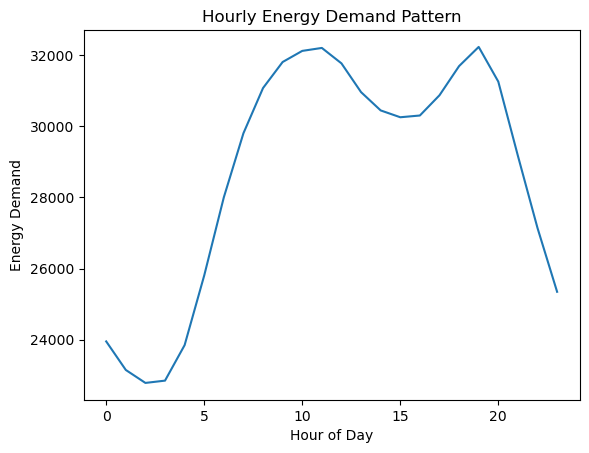

In [8]:
import matplotlib.pyplot as plt

plt.figure()
hourly.plot()
plt.title("Hourly Energy Demand Pattern")
plt.xlabel("Hour of Day")
plt.ylabel("Energy Demand")
plt.show()

In [9]:
monthly = df.groupby('month')['energy'].mean()
monthly

month
1     29804.166723
2     29502.443910
3     28622.571237
4     27600.841684
5     27661.281534
6     28979.681834
7     29929.972091
8     28576.720430
9     28326.569295
10    27669.932751
11    29114.565671
12    28623.967731
Name: energy, dtype: float64

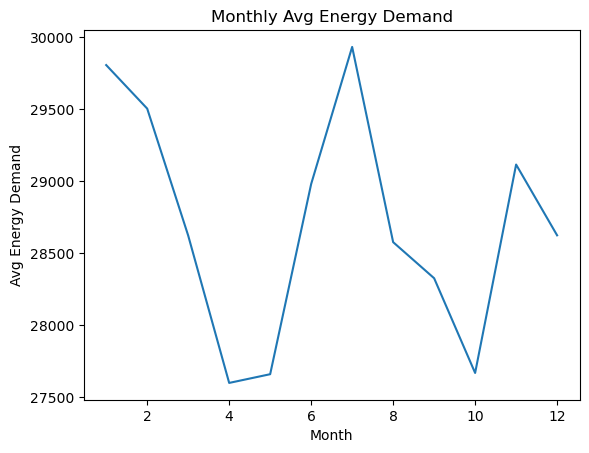

In [10]:
plt.figure()
monthly.plot()
plt.title("Monthly Avg Energy Demand")
plt.xlabel("Month")
plt.ylabel("Avg Energy Demand")
plt.show()

In [11]:
daily = df.groupby('day')['energy'].sum()
daily

day
1     32947847.0
2     35767838.0
3     33699539.0
4     31261344.0
5     30621626.0
6     32119848.0
7     34617889.0
8     34128328.0
9     33080997.0
10    31071261.0
11    31754162.0
12    33634613.0
13    33441318.0
14    33121963.0
15    32755717.0
16    33105973.0
17    33055264.0
18    33232928.0
19    33419294.0
20    33646411.0
21    33499238.0
22    33372760.0
23    33369516.0
24    32783722.0
25    32333245.0
26    33059346.0
27    33502799.0
28    33088641.0
29    30799902.0
30    29982599.0
31    18920483.0
Name: energy, dtype: float64

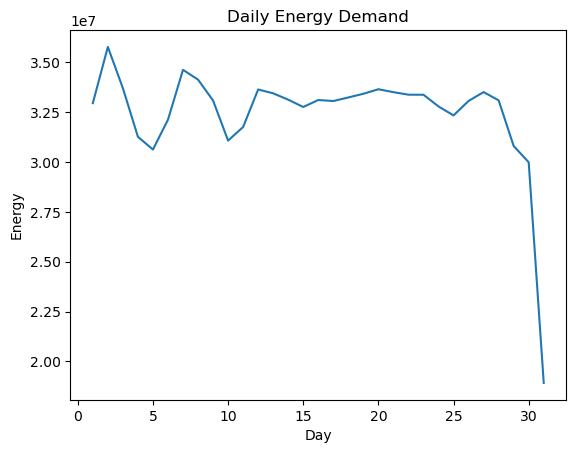

In [12]:
import matplotlib.pyplot as plt

plt.figure()
daily.plot()
plt.title("Daily Energy Demand")
plt.xlabel("Day")
plt.ylabel("Energy")
plt.show()

In [13]:
import sqlite3

In [14]:
conn = sqlite3.connect("energy.db")

In [15]:
hourly.to_sql("hourly_energy", conn, if_exists="replace")
monthly.to_sql("monthly_energy", conn, if_exists="replace")
daily.to_sql("daily_energy", conn, if_exists="replace")

31

In [16]:
pd.read_sql("SELECT * FROM hourly_energy LIMIT 5", conn)

,hour,energy
0,0,23951.776865
1,1,23149.849212
2,2,22785.642710
3,3,22850.080822
4,4,23847.329911


In [17]:
hourly.to_csv("hourly_energy.csv")
monthly.to_csv("monthly_energy.csv")
daily.to_csv("daily_energy.csv")

In [18]:
import os
os.listdir()

['.ipynb_checkpoints',
 'daily_energy.csv',
 'energy.db',
 'energy_dataset.csv',
 'hourly_energy.csv',
 'monthly_energy.csv',
 'project.ipynb']

In [19]:
print(df.columns.tolist())

['time', 'generation biomass', 'generation fossil brown coal/lignite', 'generation fossil coal-derived gas', 'generation fossil gas', 'generation fossil hard coal', 'generation fossil oil', 'generation fossil oil shale', 'generation fossil peat', 'generation geothermal', 'generation hydro pumped storage aggregated', 'generation hydro pumped storage consumption', 'generation hydro run-of-river and poundage', 'generation hydro water reservoir', 'generation marine', 'generation nuclear', 'generation other', 'generation other renewable', 'generation solar', 'generation waste', 'generation wind offshore', 'generation wind onshore', 'forecast solar day ahead', 'forecast wind offshore eday ahead', 'forecast wind onshore day ahead', 'total load forecast', 'total load actual', 'price day ahead', 'price actual', 'hour', 'day', 'month', 'energy']


In [20]:

print("=" * 45)
print("        ENERGY DEMAND - KPI SUMMARY")
print("=" * 45)
print(f"Total Records          : {len(df):,}")
print(f"Date Range             : {df['time'].min().date()} to {df['time'].max().date()}")
print(f"Average Hourly Demand  : {df['energy'].mean():,.0f} MW")
print(f"Peak Demand Value      : {df['energy'].max():,.0f} MW")
print(f"Minimum Demand Value   : {df['energy'].min():,.0f} MW")
print(f"Peak Hour of Day       : Hour {hourly.idxmax()}")
print(f"Highest Demand Month   : Month {monthly.idxmax()}")
print(f"Average Price (Actual) : {df['price actual'].mean():.2f} EUR/MWh")
print(f"Max Price (Actual)     : {df['price actual'].max():.2f} EUR/MWh")
print("=" * 45)

        ENERGY DEMAND - KPI SUMMARY
Total Records          : 35,028
Date Range             : 2014-12-31 to 2018-12-31
Average Hourly Demand  : 28,697 MW
Peak Demand Value      : 41,015 MW
Minimum Demand Value   : 18,041 MW
Peak Hour of Day       : Hour 19
Highest Demand Month   : Month 7
Average Price (Actual) : 57.89 EUR/MWh
Max Price (Actual)     : 116.80 EUR/MWh


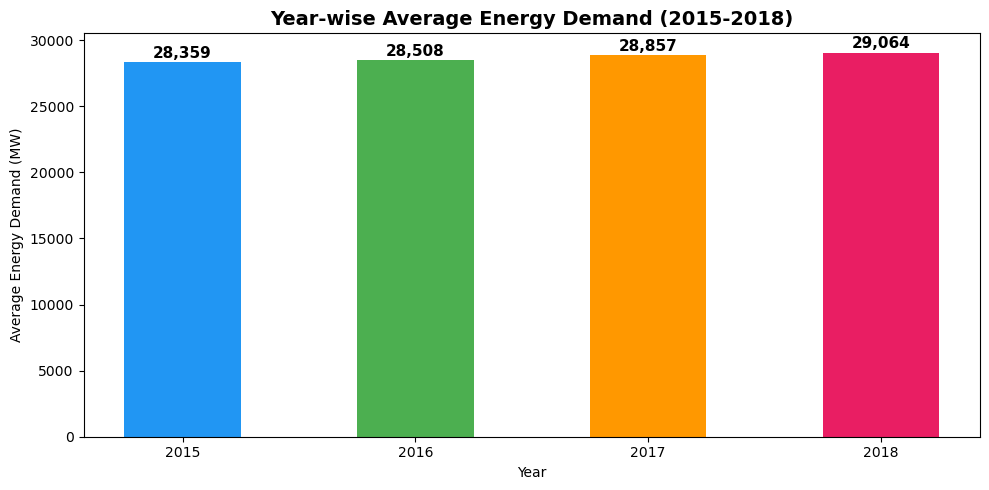

yearly_energy.csv exported


In [22]:

df['year'] = df['time'].dt.year


df = df[df['year'] >= 2015]

yearly = df.groupby('year')['energy'].mean()

plt.figure(figsize=(10, 5))
bars = plt.bar(yearly.index, yearly.values, color=['#2196F3','#4CAF50','#FF9800','#E91E63'], width=0.5)
for bar, val in zip(bars, yearly.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
             f'{val:,.0f}', ha='center', va='bottom', fontsize=11, fontweight='bold')
plt.title("Year-wise Average Energy Demand (2015-2018)", fontsize=14, fontweight='bold')
plt.xlabel("Year")
plt.ylabel("Average Energy Demand (MW)")
plt.xticks([2015, 2016, 2017, 2018])
plt.tight_layout()
plt.show()

yearly.to_csv("yearly_energy.csv")
print("yearly_energy.csv exported")

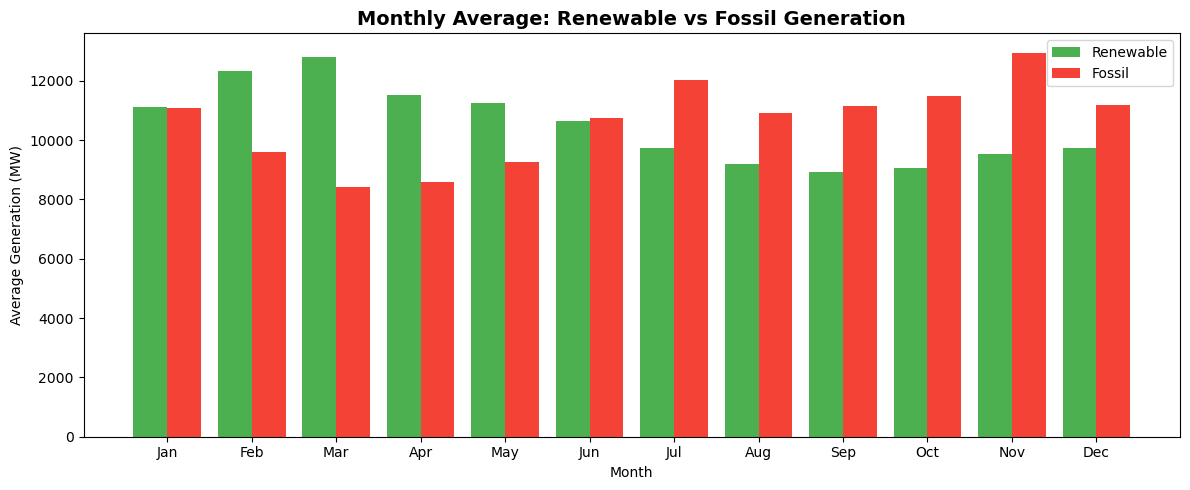

renewable_vs_fossil.csv exported


In [23]:

df['total_renewable'] = (
    df['generation solar'].fillna(0) +
    df['generation wind onshore'].fillna(0) +
    df['generation wind offshore'].fillna(0) +
    df['generation hydro run-of-river and poundage'].fillna(0) +
    df['generation hydro water reservoir'].fillna(0)
)

df['total_fossil'] = (
    df['generation fossil gas'].fillna(0) +
    df['generation fossil hard coal'].fillna(0) +
    df['generation fossil brown coal/lignite'].fillna(0) +
    df['generation fossil oil'].fillna(0)
)

monthly_renewable = df.groupby('month')['total_renewable'].mean()
monthly_fossil    = df.groupby('month')['total_fossil'].mean()

x = monthly_renewable.index
width = 0.4

plt.figure(figsize=(12, 5))
plt.bar(x - width/2, monthly_renewable.values, width, label='Renewable', color='#4CAF50')
plt.bar(x + width/2, monthly_fossil.values,    width, label='Fossil',    color='#F44336')
plt.title("Monthly Average: Renewable vs Fossil Generation", fontsize=14, fontweight='bold')
plt.xlabel("Month")
plt.ylabel("Average Generation (MW)")
plt.xticks(range(1,13), ['Jan','Feb','Mar','Apr','May','Jun',
                          'Jul','Aug','Sep','Oct','Nov','Dec'])
plt.legend()
plt.tight_layout()
plt.show()

renewable_fossil = pd.DataFrame({
    'month': x,
    'renewable': monthly_renewable.values,
    'fossil':    monthly_fossil.values
})
renewable_fossil.to_csv("renewable_vs_fossil.csv", index=False)
print("renewable_vs_fossil.csv exported")

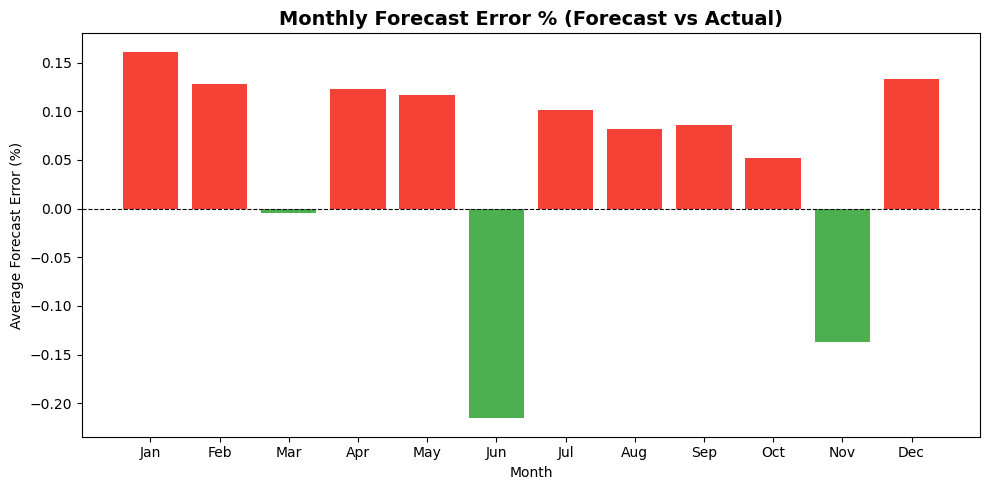

Overall avg forecast error: 0.05%
Best month (lowest error) : Month 3


In [24]:


df['forecast_error'] = df['total load forecast'] - df['total load actual']
df['forecast_error_pct'] = (df['forecast_error'] / df['total load actual']) * 100

monthly_error = df.groupby('month')['forecast_error_pct'].mean()

plt.figure(figsize=(10, 5))
colors = ['#F44336' if v > 0 else '#4CAF50' for v in monthly_error.values]
plt.bar(monthly_error.index, monthly_error.values, color=colors)
plt.axhline(y=0, color='black', linewidth=0.8, linestyle='--')
plt.title("Monthly Forecast Error % (Forecast vs Actual)", fontsize=14, fontweight='bold')
plt.xlabel("Month")
plt.ylabel("Average Forecast Error (%)")
plt.xticks(range(1,13), ['Jan','Feb','Mar','Apr','May','Jun',
                          'Jul','Aug','Sep','Oct','Nov','Dec'])
plt.tight_layout()
plt.show()

print(f"Overall avg forecast error: {df['forecast_error_pct'].mean():.2f}%")
print(f"Best month (lowest error) : Month {monthly_error.abs().idxmin()}")

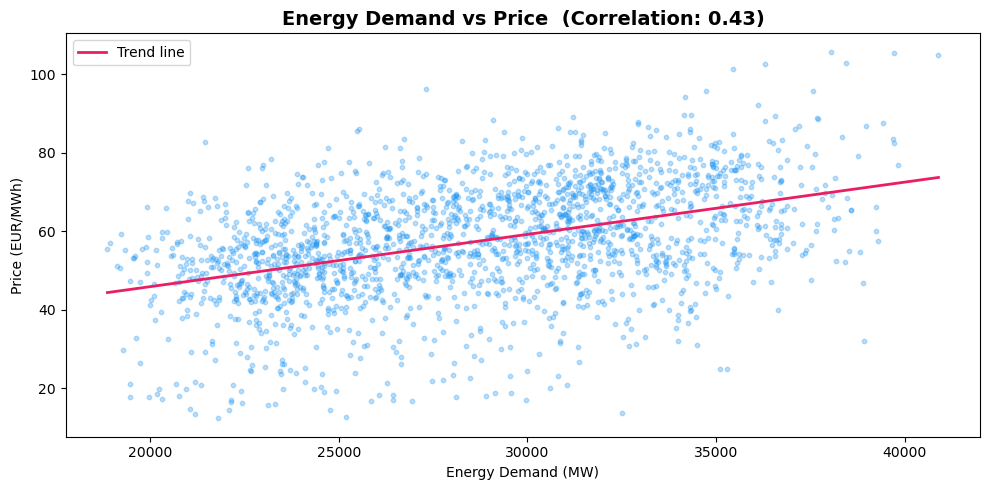

price_vs_demand.csv exported


In [25]:

import numpy as np

sample = df[['energy','price actual']].dropna().sample(2000, random_state=42)

plt.figure(figsize=(10, 5))
plt.scatter(sample['energy'], sample['price actual'],
            alpha=0.3, color='#2196F3', s=10)


z = np.polyfit(sample['energy'], sample['price actual'], 1)
p = np.poly1d(z)
x_line = np.linspace(sample['energy'].min(), sample['energy'].max(), 100)
plt.plot(x_line, p(x_line), color='#E91E63', linewidth=2, label='Trend line')

corr = sample['energy'].corr(sample['price actual'])
plt.title(f"Energy Demand vs Price  (Correlation: {corr:.2f})", fontsize=14, fontweight='bold')
plt.xlabel("Energy Demand (MW)")
plt.ylabel("Price (EUR/MWh)")
plt.legend()
plt.tight_layout()
plt.show()

price_demand = df[['energy','price actual']].dropna()
price_demand.columns = ['energy', 'price']
price_demand.to_csv("price_vs_demand.csv", index=False)
print("price_vs_demand.csv exported")

In [26]:


yearly.to_sql("yearly_energy", conn, if_exists="replace")
renewable_fossil.to_sql("renewable_vs_fossil", conn, if_exists="replace")
price_demand.to_sql("price_vs_demand", conn, if_exists="replace")

print("All new tables saved to energy.db")
print(os.listdir())

All new tables saved to energy.db
['.ipynb_checkpoints', 'daily_energy.csv', 'energy.db', 'energy_dataset.csv', 'hourly_energy.csv', 'monthly_energy.csv', 'price_vs_demand.csv', 'project.ipynb', 'renewable_vs_fossil.csv', 'yearly_energy.csv']


In [27]:
# Restructure renewable_vs_fossil for Tableau side-by-side bars
renewable_long = pd.DataFrame({
    'Month': list(range(1,13)) + list(range(1,13)),
    'Type': ['Renewable']*12 + ['Fossil']*12,
    'Value': list(monthly_renewable.values) + list(monthly_fossil.values)
})
renewable_long.to_csv("renewable_vs_fossil_long.csv", index=False)
print(renewable_long.head())
print("Done!")

   Month       Type         Value
0      1  Renewable  11119.836982
1      2  Renewable  12325.263976
2      3  Renewable  12790.464046
3      4  Renewable  11508.456507
4      5  Renewable  11253.614194
Done!
